#ASL Dataset Visulisation

In [ ]:
# All imports for model here
import tensorflow as tf

from tensorflow.keras.applications import MobileNet, ResNet50, InceptionV3
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import seaborn as sns
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
!pip install tensorflowjs
import tensorflowjs as tfjs
import shutil
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Visulizing Random samples from dataset this displays a few random images from the dataset to get a sense of how the data is structured.it displays a grid of random images from different classes which in this case is the letters of ASL alphabet in the dataset.

In [ ]:
# Path to training data
train_dir = '/content/drive/MyDrive/ASL Dataset/train'

class_labels = os.listdir(train_dir)

image_size = (224, 224)
#Function to visulise samples
def visualize_samples(class_labels, train_dir, num_samples=5):
    plt.figure(figsize=(10, 10))


    for i, label in enumerate(class_labels[:num_samples]):
        label_path = os.path.join(train_dir, label)
        image_paths = os.listdir(label_path)


        image_path = os.path.join(label_path, np.random.choice(image_paths))


        img = load_img(image_path, target_size=image_size)
        img_array = img_to_array(img) / 255.0

        # Display the image
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_array)
        plt.title(f"Class: {label}")
        plt.axis('off')

    plt.show()

# Visualize random samples
visualize_samples(class_labels, train_dir)

ValueError: 'a' cannot be empty unless no samples are taken

<Figure size 1000x1000 with 0 Axes>

This block of code is to visulize the augmentation effects on the image after its been augmented This will generate and display 5 augmented images of a sample image from the A class, showing how the dataset is transformed by the augmentations (rotation, zoom, flip, etc.).

In [ ]:


image_size = (224, 224)


datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=30,  # Random rotation

)

train_dir = '/content/drive/MyDrive/ASL Dataset/train'  #training data path


image_path = os.path.join(train_dir, 'A', np.random.choice( os.listdir(os.path.join(train_dir, 'A'))))

img = load_img(image_path, target_size=image_size)
img_array = img_to_array(img)


img_array = img_array.reshape((1,) + img_array.shape)

# Generate augmented images and display them
i = 0
plt.figure(figsize=(10, 10))
for batch in datagen.flow(img_array, batch_size=1, save_to_dir='/content/', save_prefix='aug', save_format='jpeg'):
    plt.subplot(1, 5, i+1)
    plt.imshow(batch[0])  # Display the augmented image
    plt.axis('off')
    i += 1
    if i >= 5:  # Generate 5 augmented images
        break
plt.show()

 This block of code is used to check if the dataset is balanced across classes by checking If some letters have fewer images than others The bar plot is used show the distribution of images across different letters of the ASL alphabet.

In [ ]:


class_counts = [len(os.listdir(os.path.join(train_dir, label))) for label in class_labels]

# This plots the distribution of images per class
plt.figure(figsize=(12, 6))
sns.barplot(x=class_labels, y=class_counts)
plt.title("Distribution of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

# Training ASL Dataset

Normalising The images

In [ ]:
# Original dataset directory
original_dataset_dir = '/content/drive/MyDrive/ASL Dataset/train'

# Define split directories
train_dir = '/content/drive/MyDrive/ASL Dataset/split/train'
val_dir = '/content/drive/MyDrive/ASL Dataset/split/validation'
test_dir = '/content/drive/MyDrive/ASL Dataset/split/test'

# Create directories for splits
for dir_path in [train_dir, val_dir, test_dir]:
    os.makedirs(dir_path, exist_ok=True)

# Split process with tqdm progress bar
for label in os.listdir(original_dataset_dir):
    label_dir = os.path.join(original_dataset_dir, label)

    # Ensure it's a directory
    if not os.path.isdir(label_dir):
        print(f"Skipping non-directory: {label_dir}")
        continue

    images = os.listdir(label_dir)
    images = [img for img in images if not img.startswith('.')]  # Exclude hidden files

    # Check if images exist
    if not images:
        print(f"No images found in: {label_dir}")
        continue

    print(f"Processing class: {label}, Number of images: {len(images)}")

    # Split into train, validation, and test
    train_images, temp_images = train_test_split(images, test_size=0.3, random_state=42)  # 70% train, 30% val+test
    val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)  # 15% val, 15% test

    # Move files to corresponding split directories
    for split_dir, split_images in zip([train_dir, val_dir, test_dir], [train_images, val_images, test_images]):
        split_label_dir = os.path.join(split_dir, label)
        os.makedirs(split_label_dir, exist_ok=True)

        for img in tqdm(split_images, desc=f"Processing {label} for {split_dir}"):
            src = os.path.join(label_dir, img)
            dest = os.path.join(split_label_dir, img)
            shutil.move(src, dest)  # Faster than copy

print("Dataset split process completed!")



# Image size and batch size
image_size = (112, 112)
batch_size = 16

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Validation generator
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Test generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Ensure consistent ordering
)

# Handling class imbalance
class_labels = list(train_generator.class_indices.keys())
y_true = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true),
    y=y_true
)
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

No images found in: /content/drive/MyDrive/ASL Dataset/train/H
No images found in: /content/drive/MyDrive/ASL Dataset/train/B
No images found in: /content/drive/MyDrive/ASL Dataset/train/I
No images found in: /content/drive/MyDrive/ASL Dataset/train/D
No images found in: /content/drive/MyDrive/ASL Dataset/train/G
No images found in: /content/drive/MyDrive/ASL Dataset/train/E
No images found in: /content/drive/MyDrive/ASL Dataset/train/A
No images found in: /content/drive/MyDrive/ASL Dataset/train/J
No images found in: /content/drive/MyDrive/ASL Dataset/train/C
No images found in: /content/drive/MyDrive/ASL Dataset/train/F
No images found in: /content/drive/MyDrive/ASL Dataset/train/S
No images found in: /content/drive/MyDrive/ASL Dataset/train/N
No images found in: /content/drive/MyDrive/ASL Dataset/train/P
No images found in: /content/drive/MyDrive/ASL Dataset/train/O
No images found in: /content/drive/MyDrive/ASL Dataset/train/R
No images found in: /content/drive/MyDrive/ASL Dataset/

In [ ]:
def build_model_with_base(base_model, num_classes):
    # Set the pre-trained base model,
    for layer in base_model.layers[:-10]:  # Freeze all layers except the last 10
        layer.trainable = False


    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)  #  dense layer for fine-tuning
    predictions = layers.Dense(num_classes, activation='softmax')(x)  # Output layer

    # Construct model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [ ]:
# Load pre-trained models
mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(112, 112, 3))
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(112, 112, 3))
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(112, 112, 3))

# Number of output classes
num_classes = len(class_labels)

# Build models with different base architectures
mobilenet_model = build_model_with_base(mobilenet_base, num_classes)
resnet_model = build_model_with_base(resnet_base, num_classes)
inception_model = build_model_with_base(inception_base, num_classes)


<ipython-input-12-eee1394ea0f1>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(112, 112, 3))


In [ ]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

#tf.data pipeline for prefetching
def generator_to_tfdata(generator):
    return tf.data.Dataset.from_generator(
        lambda: generator,
        output_signature=(
            tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, len(class_labels)), dtype=tf.float32)
        )
    ).prefetch(buffer_size=tf.data.AUTOTUNE)

train_dataset = generator_to_tfdata(train_generator)
val_dataset = generator_to_tfdata(val_generator)

In [ ]:
history_mobilenet = mobilenet_model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights_dict)
history_resnet = resnet_model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights_dict)
history_inception = inception_model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights_dict)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 1967s 4s/step - accuracy: 0.6895 - loss: 1.6926 - val_accuracy: 0.7077 - val_loss: 1.1627
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 383ms/step - accuracy: 0.9316 - loss: 0.2759 - val_accuracy: 0.8014 - val_loss: 0.6471
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 384ms/step - accuracy: 0.9476 - loss: 0.2208 - val_accuracy: 0.8668 - val_loss: 1.0743
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 206s 421ms/step - accuracy: 0.9676 - loss: 0.1432 - val_accuracy: 0.9682 - val_loss: 0.1343
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 189s 385ms/step - accuracy: 0.9642 - loss: 0.1807 - val_accuracy: 0.9918 - val_loss: 0.0377
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 189s 386ms/step - accuracy: 0.9740 - loss: 0.1297 - val_accuracy: 0.9546 - val_loss: 0.3822
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 383ms/step - accuracy: 0.9853 - loss: 0.0901 - val_accuracy: 0.8079 - val_loss: 1.9094
Epoch 8/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 187s 382ms/step - accuracy: 0.9703 - l

# Evaluating The Model

In [ ]:
# Evaluate each model on the test set without class_weight
test_loss_mobilenet, test_acc_mobilenet = mobilenet_model.evaluate(test_generator)
test_loss_resnet, test_acc_resnet = resnet_model.evaluate(test_generator)
test_loss_inception, test_acc_inception = inception_model.evaluate(test_generator)

print(f"MobileNetV2 Test Accuracy: {test_acc_mobilenet}")
print(f"ResNet50 Test Accuracy: {test_acc_resnet}")
print(f"InceptionV3 Test Accuracy: {test_acc_inception}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


106/106 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.9986 - loss: 0.0095
106/106 ━━━━━━━━━━━━━━━━━━━━ 85s 805ms/step - accuracy: 0.8816 - loss: 0.3308
106/106 ━━━━━━━━━━━━━━━━━━━━ 47s 447ms/step - accuracy: 0.8959 - loss: 0.4424
MobileNetV2 Test Accuracy: 0.9952802062034607
ResNet50 Test Accuracy: 0.886725664138794
InceptionV3 Test Accuracy: 0.895575225353241


In [ ]:
# Generate predictions for the test set
y_pred_mobilenet = mobilenet_model.predict(test_generator)
y_pred_resnet = resnet_model.predict(test_generator)
y_pred_inception = inception_model.predict(test_generator)

# Get predicted classes
y_pred_mobilenet_classes = np.argmax(y_pred_mobilenet, axis=1)
y_pred_resnet_classes = np.argmax(y_pred_resnet, axis=1)
y_pred_inception_classes = np.argmax(y_pred_inception, axis=1)


106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 220ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 90s 831ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 477ms/step


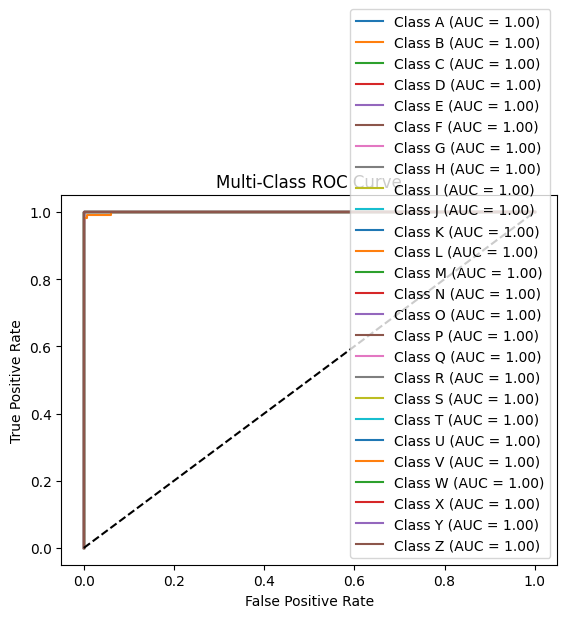

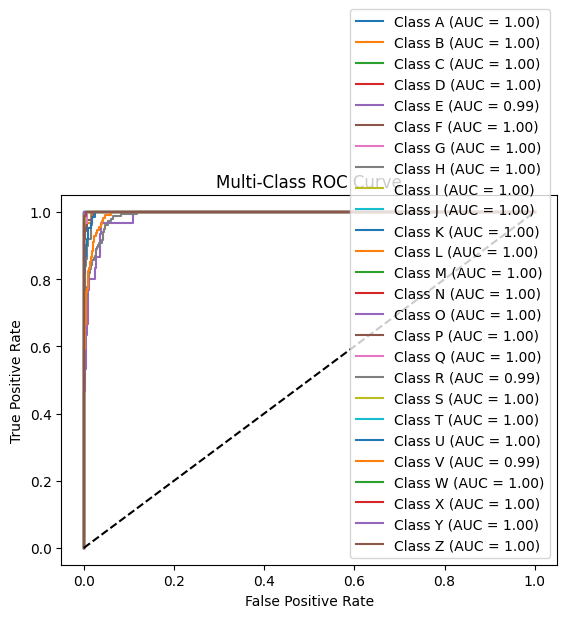

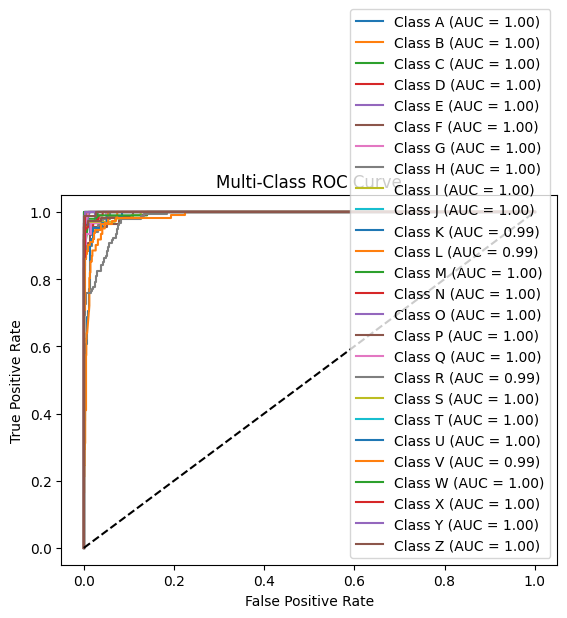

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_precision_recall_curve_multiclass(y_true, y_pred, class_labels):
    # Loop through each class and plot the precision-recall curve
    for i in range(len(class_labels)):
        precision, recall, _ = precision_recall_curve(y_true == i, y_pred[:, i])
        plt.plot(recall, precision, label=f'Class {class_labels[i]}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Multiclass Precision-Recall Curve')
    plt.legend()
    plt.show()



def plot_multi_class_roc_curve(y_true, y_pred, class_labels):
    # Binarize the labels for multi-class ROC curve
    y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))

    # Loop through each class and compute ROC curve and AUC
    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc='lower right')
    plt.show()


plot_multi_class_roc_curve(test_generator.classes, y_pred_mobilenet, class_labels)
plot_multi_class_roc_curve(test_generator.classes, y_pred_resnet, class_labels)
plot_multi_class_roc_curve(test_generator.classes, y_pred_inception, class_labels)


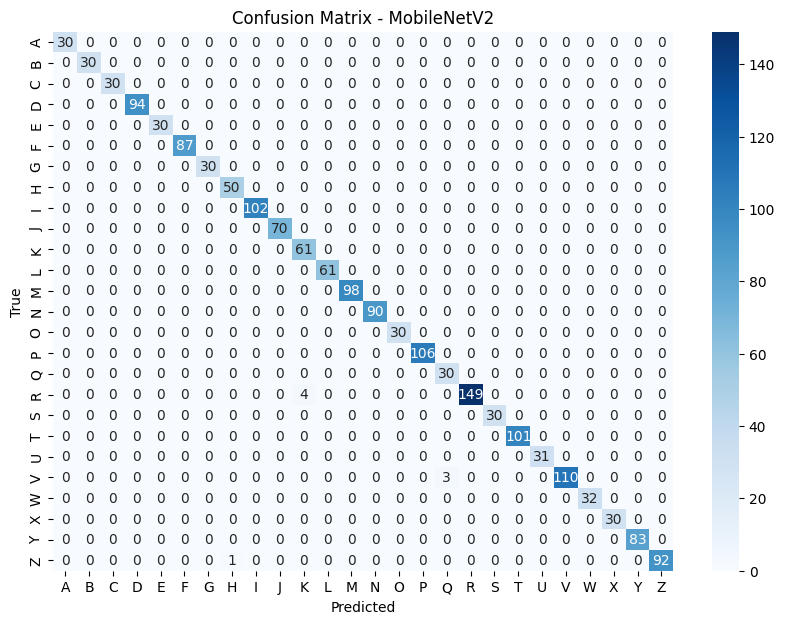

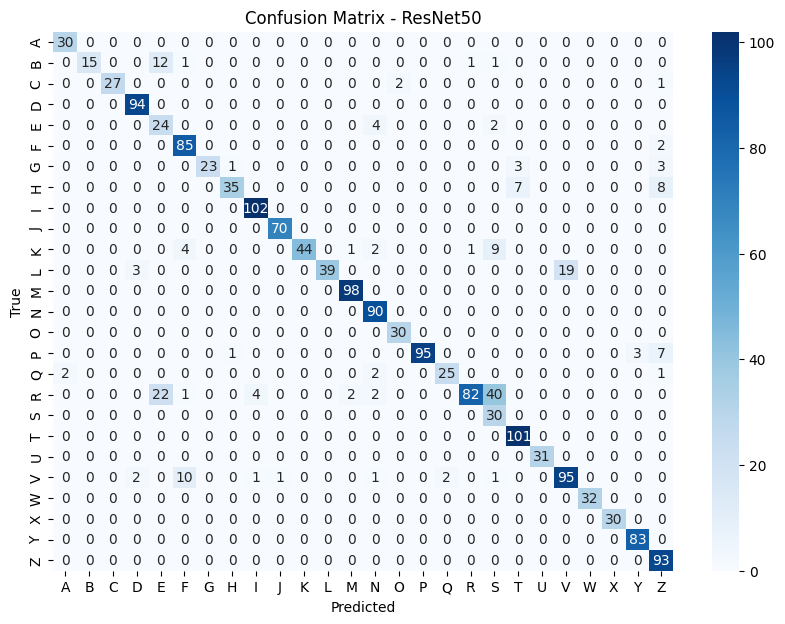

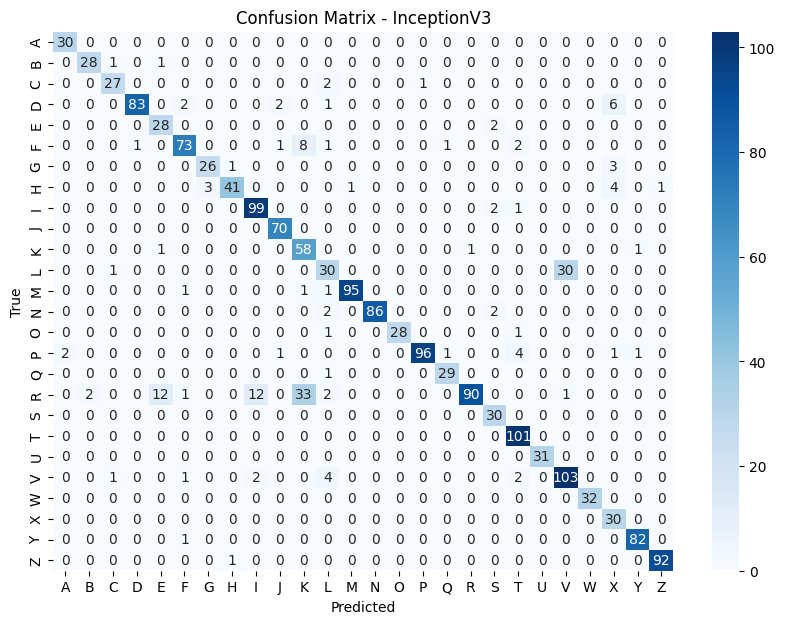

In [ ]:
plot_confusion_matrix(test_generator.classes, y_pred_mobilenet_classes, 'MobileNetV2', class_labels)
plot_confusion_matrix(test_generator.classes, y_pred_resnet_classes, 'ResNet50', class_labels)
plot_confusion_matrix(test_generator.classes, y_pred_inception_classes, 'InceptionV3', class_labels)


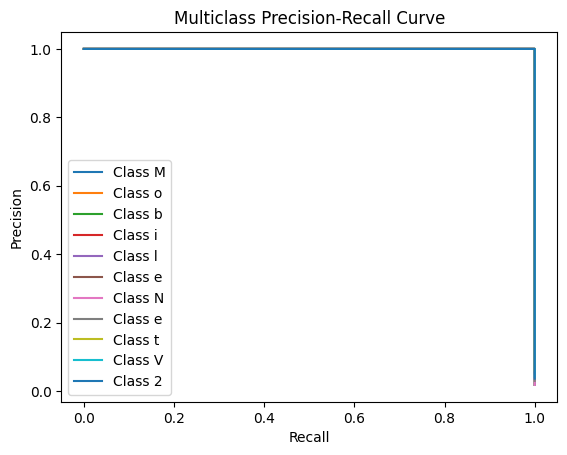

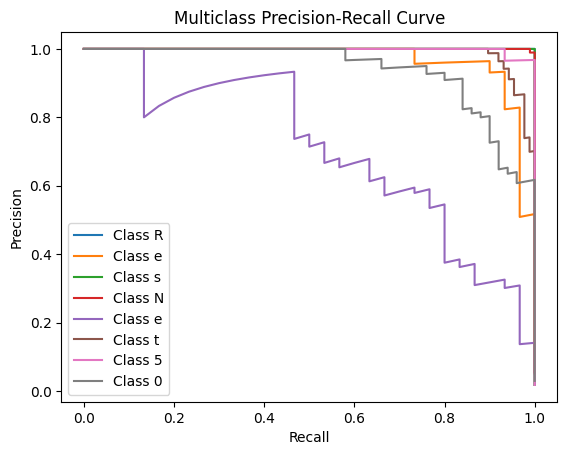

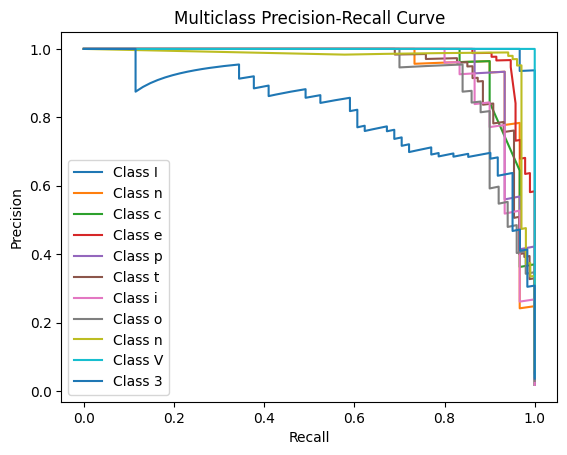

In [ ]:
plot_precision_recall_curve_multiclass(test_generator.classes, y_pred_mobilenet, 'MobileNetV2')
plot_precision_recall_curve_multiclass(test_generator.classes, y_pred_resnet, 'ResNet50')
plot_precision_recall_curve_multiclass(test_generator.classes, y_pred_inception, 'InceptionV3')

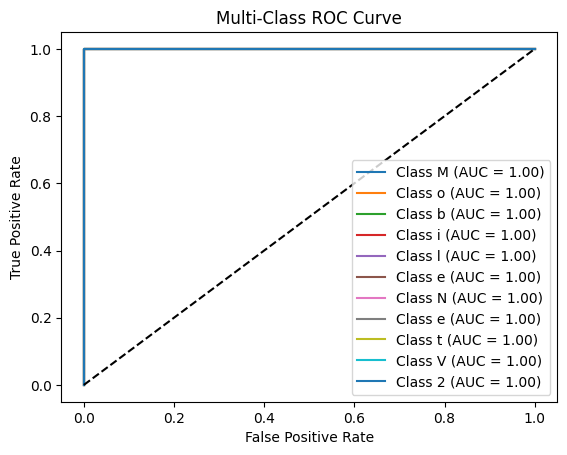

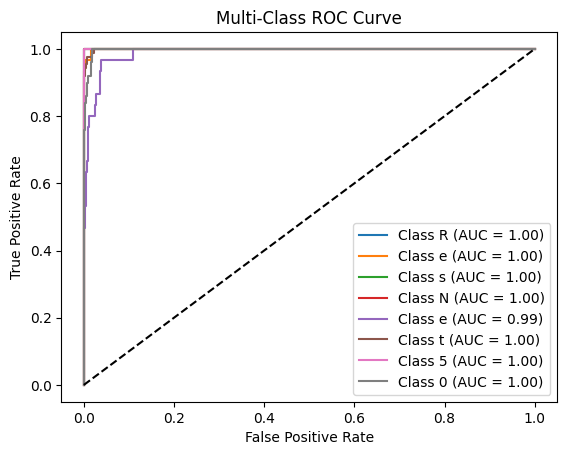

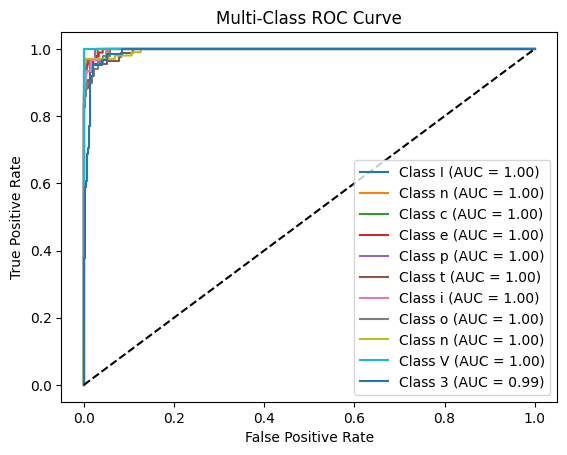

In [ ]:
plot_multi_class_roc_curve(test_generator.classes, y_pred_mobilenet, 'MobileNetV2')
plot_multi_class_roc_curve(test_generator.classes, y_pred_resnet, 'ResNet50')
plot_multi_class_roc_curve(test_generator.classes, y_pred_inception, 'InceptionV3')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


106/106 ━━━━━━━━━━━━━━━━━━━━ 1350s 13s/step
Test F1 Score: 1.00


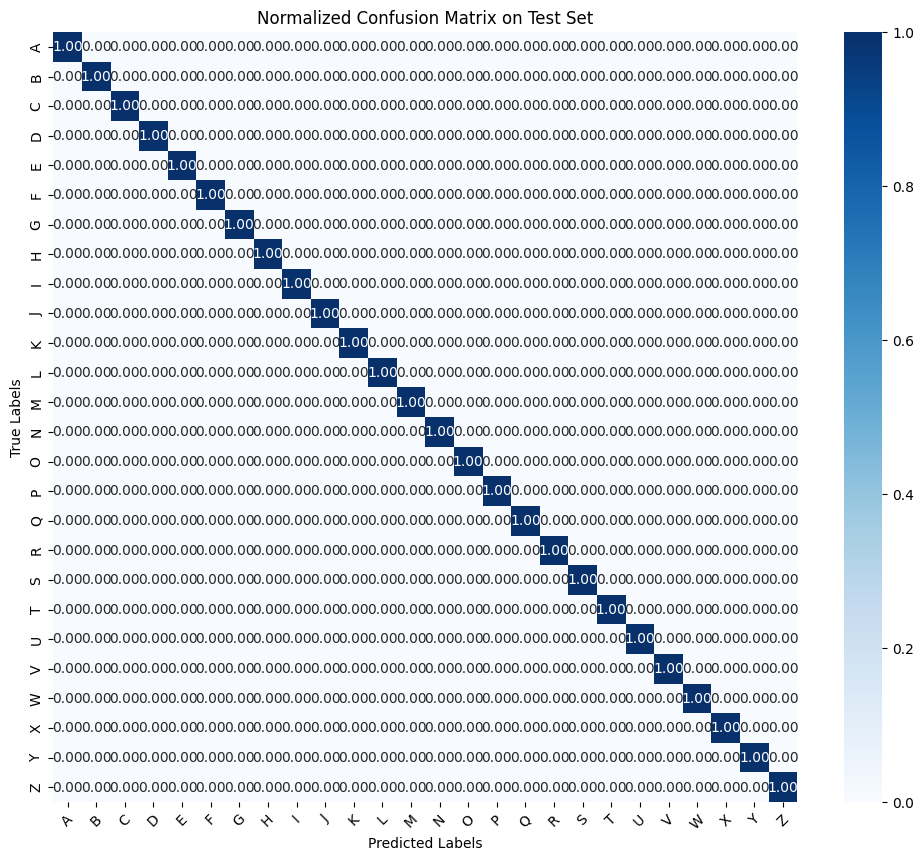

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 754ms/step - accuracy: 0.9983 - loss: 0.0052
Validation Accuracy: 0.9971


In [ ]:
y_test_probs = model.predict(test_generator)
y_test_pred = np.argmax(y_test_probs, axis=1)
y_test_true = test_generator.classes

# Compute F1 score
f1_test = f1_score(y_test_true, y_test_pred, average='weighted')
print(f"Test F1 Score: {f1_test:.2f}")

# Plot confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_normalized = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_test_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys(),
    cbar=True
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix on Test Set')
plt.xticks(rotation=45)
plt.show()

# Printing validation accuracy
val_loss, val_accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy:.4f}")


In [ ]:

model.save(model.h5")
model = tf.keras.models.load_model("model.h5")


inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")
outputs = model(inputs)  # Pass through existing model
new_model = tf.keras.Model(inputs=inputs, outputs=outputs)
new_model.summary()

# Convert & Save Model for TensorFlow.js
tfjs_target_dir = "tfjs_model"
tfjs.converters.save_keras_model(new_model, tfjs_target_dir)
print(f"Model converted and saved in {tfjs_target_dir}")
shutil.make_archive("tfjs_model", 'zip', "tfjs_model")
print(" Model successfully converted and zipped.")
files.download("tfjs_model.zip")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ functional (Functional)              │ (None, 26)                  │       3,497,946 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,497,946 (13.34 MB)

 Trainable params: 1,857,306 (7.09 MB)

 Non-trainable params: 1,640,640 (6.26 MB)

failed to lookup keras version from the file,
    this is likely a weight only file
🔥 Model converted and saved in tfjs_model 🔥
✅ Model successfully converted and zipped.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>